# Introduction to Random Forest Classification: Rainfall-Induced Landslides

(with a comparison to XGBoost at the end)

In this notebook, we will use **Random Forest Classification** to predict rainfall-induced landslides. In hydrology and geomorphology, scientists study the **Rainfall Intensity-Duration ($I$-$D$) relationship** to establish empirical thresholds for landslide triggering. One of the key papers describing this relationship is described in Caine, 1980: The Rainfall Intensity: Duration Control of Shallow Landslides and Debris Flows, https://doi.org/10.2307/520449

We will cover:
1. Simulating a synthetic $I$-$D$ landslide threshold dataset.
2. Understanding **Bagging** (Bootstrap Aggregating) and averaging trees
3. Training a Random Forest Classifier using `scikit-learn`.
4. Visualizing and interpreting **Feature Importance**.
5. Hyperparameter Tuning
6. Comparison to XGBoost


# Step 1: Import Libraries
First, let's import the necessary Python packages for data manipulation, machine learning, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

# Set seed for reproducibility
np.random.seed(42)
sns.set_theme(style="whitegrid")

# Step 2: Generate Synthetic I-D Relationship Dataset
We will generate $1,000$ storm events. Each event has a random `Duration` ($D$ in hours) and `Intensity` ($I$ in mm/h). 

A storm triggers a landslide ($1$) if its intensity exceeds the empirical physical threshold: 
$$I_{threshold} = 15 \cdot D^{-0.4}$$
plus some random environmental noise (e.g., varying antecedent soil moisture conditions).

In [2]:
# Generate 1,000 synthetic storm events
n_samples = 1000
duration = np.random.uniform(0.01, 72, n_samples) # Storm durations from 1 to 72 hours

# Base intensity with some exponential decay based on duration
intensity = np.random.exponential(scale=10, size=n_samples) + 1 

# Define the physical landslide threshold: I = 15 * D^(-0.4)
threshold_intensity = 15 * (duration ** -0.4)

# Add some random environmental noise to the threshold boundary
noise = np.random.normal(0, 1.5, n_samples)
landslide_triggered = (intensity > (threshold_intensity + noise)).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'Duration_hours': duration,
    'Intensity_mm_h': intensity,
    'Total_Rainfall_mm': duration * intensity, # Highly correlated feature
    'Landslide': landslide_triggered
})

print("--- Dataset Preview ---")
print(df.head())

--- Dataset Preview ---
   Duration_hours  Intensity_mm_h  Total_Rainfall_mm  Landslide
0       26.973143        3.047303          82.195335          1
1       68.451923        8.806698         602.835444          1
2       52.706244       21.631418        1140.110789          1
3       43.107424       14.176078         611.094200          1
4       11.241782       17.427938         195.921081          1


## Let's Plot Our Physical $I$-$D$ Threshold
Before feeding this into a machine learning model, let's visualize our synthetic data to see the physical boundary.

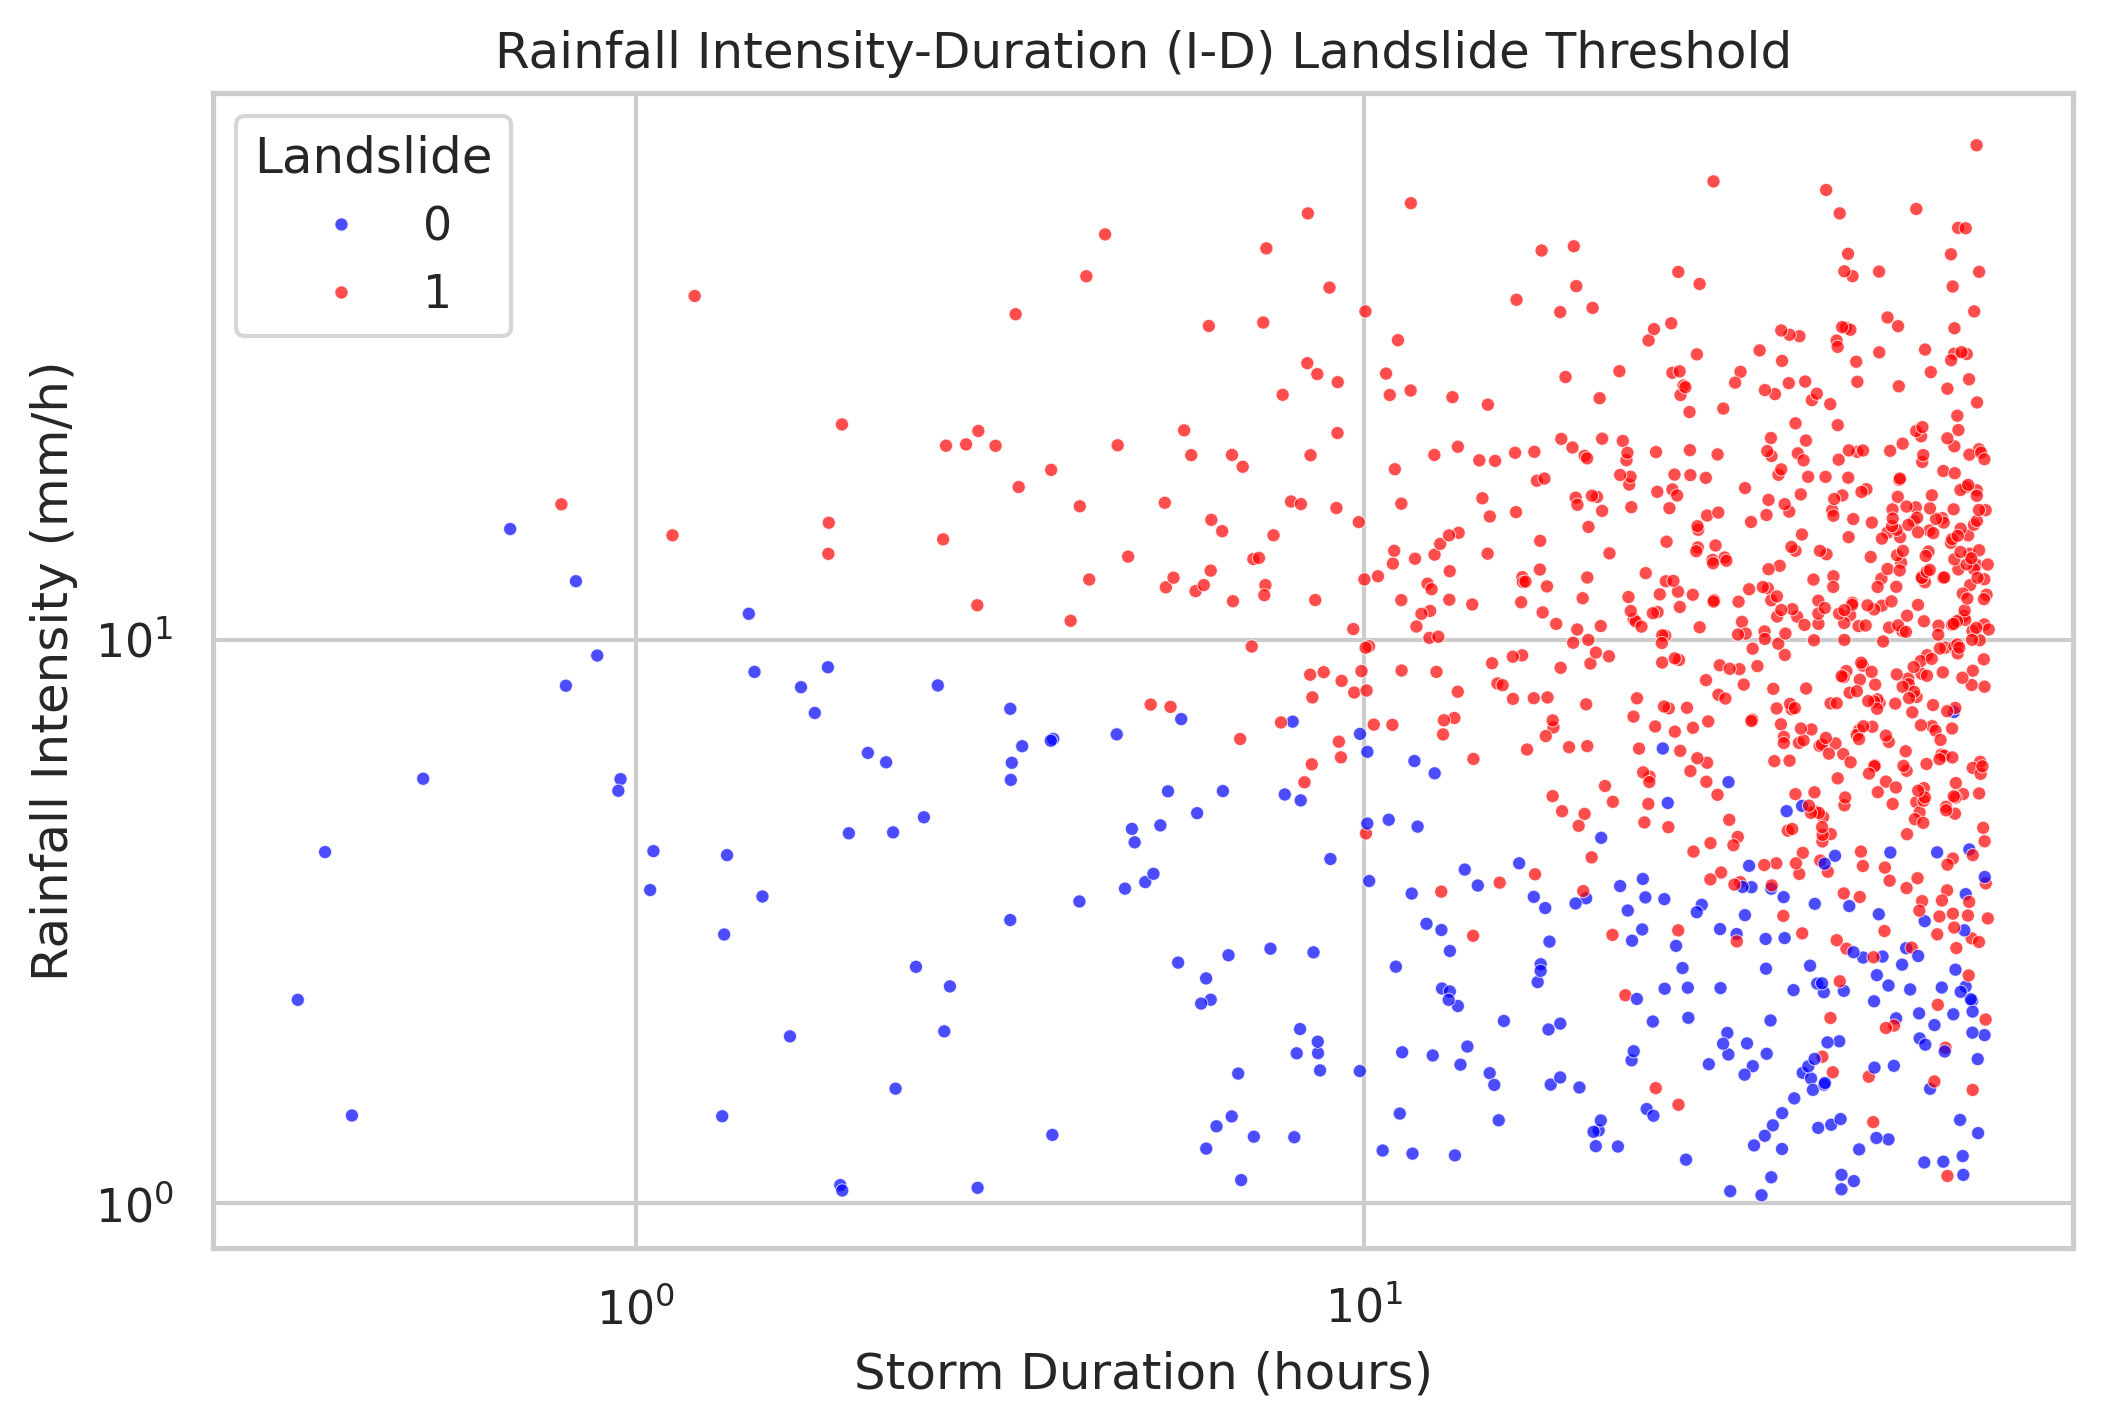

In [3]:
fig, ax = plt.subplots(1,1,figsize=(8, 5), dpi=300)
sns.scatterplot(data=df, x='Duration_hours', y='Intensity_mm_h', hue='Landslide', palette={0: 'blue', 1: 'red'}, s=10, alpha=0.7, ax=ax)
ax.set_title('Rainfall Intensity-Duration (I-D) Landslide Threshold')
ax.set_xlabel('Storm Duration (hours)')
ax.set_ylabel('Rainfall Intensity (mm/h)')
ax.set_yscale('log') # I-D curves are traditionally viewed on log scales
ax.set_xscale('log')

# Step 3: Understanding Bagging (Bootstrap Aggregating)

**What is Bagging?**

Bagging stands for **B**ootstrap **Agg**regating. It reduces a model's variance (overfitting) by:
1. **Bootstrapping:** Creating multiple subsets of the original dataset by sampling *with replacement*.
2. **Aggregating:** Training a separate Decision Tree on each subset, and letting them vote on the final classification.

Because a single decision tree might draw a highly jagged, overfitted stair-step boundary around our noisy empirical curve, Bagging averages many trees out to create a smooth, generalized boundary.

Furthermore, a **Random Forest** adds one more layer of randomness: at every split in a decision tree, it only considers a random subset of *features* (columns). This ensures that `Total_Rainfall_mm` doesn't completely mask the individual importance of `Duration_hours` or `Intensity_mm_h`.

In [4]:
# Demonstrate bootstrapping on a small subset of 5 rows
sample_demo = df[['Duration_hours', 'Intensity_mm_h']].head(5)
bootstrap_demo = sample_demo.sample(n=5, replace=True, random_state=12)

print("Original 5 Rows:")
print(sample_demo)

print("\nBootstrapped Sample (Notice repeated or missing indices):")
print(bootstrap_demo)

Original 5 Rows:
   Duration_hours  Intensity_mm_h
0       26.973143        3.047303
1       68.451923        8.806698
2       52.706244       21.631418
3       43.107424       14.176078
4       11.241782       17.427938

Bootstrapped Sample (Notice repeated or missing indices):
   Duration_hours  Intensity_mm_h
3       43.107424       14.176078
3       43.107424       14.176078
1       68.451923        8.806698
2       52.706244       21.631418
3       43.107424       14.176078


## Let's walk through an example of how you average decision trees:

### What is Bagging?
Bagging stands for Bootstrap Aggregating. It reduces a machine learning model's variance (overfitting) by combining two components:

**Bootstrapping:** Creating multiple unique sub-datasets by randomly pulling rows with replacement.

**Aggregating:** Training a completely separate decision tree on each sub-dataset, and averaging their answers via a majority vote.

Let's demystify this process by executing both steps entirely by hand using a small slice of our landslide data.

*Part A: The Bootstrap Step (Sampling with Replacement)*

Imagine we have a tiny historic record of just 5 storm events. If we want to build a new bootstrap sample, we pull 5 rows out of a hat one by one. Every time we pick a row, we record its data and put it back in the hat before drawing the next one.

In [5]:
# Grab our tiny original dataset of 5 historic storms
mini_dataset = df[['Duration_hours', 'Intensity_mm_h', 'Landslide']].head(5).copy()
mini_dataset.index.name = 'Original_Row_ID'

print("--- Original 5 Historic Storms ---")
print(mini_dataset)
print("-" * 50)

# Generate 3 distinct bootstrap samples by randomly drawing rows with replacement
np.random.seed(10) # Seed chosen to guarantee visible duplicates
bootstrap_1_idx = np.random.choice(mini_dataset.index, size=5, replace=True)
bootstrap_2_idx = np.random.choice(mini_dataset.index, size=5, replace=True)
bootstrap_3_idx = np.random.choice(mini_dataset.index, size=5, replace=True)

print(f"Tree 1's Hat pulled Row IDs: {bootstrap_1_idx.tolist()}")
print(f"Tree 2's Hat pulled Row IDs: {bootstrap_2_idx.tolist()}")
print(f"Tree 3's Hat pulled Row IDs: {bootstrap_3_idx.tolist()}")

--- Original 5 Historic Storms ---
                 Duration_hours  Intensity_mm_h  Landslide
Original_Row_ID                                           
0                     26.973143        3.047303          1
1                     68.451923        8.806698          1
2                     52.706244       21.631418          1
3                     43.107424       14.176078          1
4                     11.241782       17.427938          1
--------------------------------------------------
Tree 1's Hat pulled Row IDs: [1, 4, 0, 1, 3]
Tree 2's Hat pulled Row IDs: [4, 1, 0, 1, 2]
Tree 3's Hat pulled Row IDs: [0, 1, 0, 2, 0]


*Part B: The Aggregation Step (Majority Voting)*

Now, imagine we trained Tree 1, Tree 2, and Tree 3 on their respective bootstrap samples.

A massive new storm hits the region: Duration = 24 hours, Intensity = 6.5 mm/h. We feed this single storm into our 3 individual trees. Because they were trained on slightly different variations of historic data, they might disagree:

In [6]:
# Simulate the individual predictions from our 3 mini-decision trees
# 1 = Landslide will trigger, 0 = Safe/No Landslide
tree_1_pred = 1  # Tree 1 heavily weights intensity -> Predicts Landslide
tree_2_pred = 0  # Tree 2 saw fewer long duration events -> Predicts Safe
tree_3_pred = 1  # Tree 3 heavily weights total accumulation -> Predicts Landslide

# Create a clear voting dashboard
voting_data = pd.DataFrame({
    'Model': ['Tree 1', 'Tree 2', 'Tree 3'],
    'Prediction': [tree_1_pred, tree_2_pred, tree_3_pred]
})

print("--- Individual Tree Predictions for the New Storm ---")
print(voting_data.to_string(index=False))
print("-" * 50)

# --- The Aggregation Calculation ---
total_votes_for_landslide = voting_data['Prediction'].sum()
total_trees = len(voting_data)

# Determine ensemble conclusion using a simple majority (> 50% of trees)
if total_votes_for_landslide > (total_trees / 2):
    final_ensemble_prediction = 1
    decision_string = "Landslide (1)"
else:
    final_ensemble_prediction = 0
    decision_string = "Safe (0)"

print("--- Aggregating the Votes ---")
print(f"Votes for Landslide (1): {total_votes_for_landslide}")
print(f"Votes for Safe (0):      {total_trees - total_votes_for_landslide}")
print(f"Final Ensemble Verdict:  {decision_string}")

--- Individual Tree Predictions for the New Storm ---
 Model  Prediction
Tree 1           1
Tree 2           0
Tree 3           1
--------------------------------------------------
--- Aggregating the Votes ---
Votes for Landslide (1): 2
Votes for Safe (0):      1
Final Ensemble Verdict:  Landslide (1)


**By combining Part A and Part B, we see the usefulness of a Random Forest:**

*Error Cancellation:* Even though Tree 2 made a mistake or was biased due to its specific bootstrap slice, the collective forest still arrived at the correct physical prediction because Tree 1 and Tree 3 outvoted it.

*Feature Randomness:* A true Random Forest improves on this standard bagging approach by also restricting each tree split to a random subset of features (columns), ensuring that heavily correlated features don't steal the spotlight from individual parameters like Intensity_mm_h.

# Step 4: Split the Data and Train the Random Forest
Now, let's split our dataset into a training set ($80\%$) and a testing set ($20\%$), then fit our `RandomForestClassifier`.

In [7]:
# Separate features and target
X = df.drop(columns=['Landslide'])
y = df['Landslide']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(800, 3)
(200, 3)
(800,)
(200,)


In [8]:
X_train

,Duration_hours,Intensity_mm_h,Total_Rainfall_mm
29,3.353965,18.655975,62.571493
535,68.023685,2.299790,156.440163
695,43.968537,1.706074,75.013561
557,2.082065,6.293774,13.104046
836,65.869756,2.370757,156.161161
...,...,...,...
106,29.553467,6.045819,178.674897
270,58.275910,12.873841,750.234802
860,55.840233,15.981088,892.387654
435,50.472768,1.304320,65.832631


In [9]:
# Initialize Random Forest (100 trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print(f"Random Forest trained successfully with {rf_model.n_estimators} trees!")

Random Forest trained successfully with 100 trees!


## Visualization of the Trees

Let's plot some trees that have been used during the classification process

In [10]:
from sklearn.tree import plot_tree

# 1. Check the total number of estimators
print(f"Total trees in the forest: {len(rf_model.estimators_)}")

# 2. Inspect the depth of the first few individual trees
for i in range(3):
    tree_depth = rf_model.estimators_[i].get_depth()
    print(f"Tree {i} grew to a maximum depth of: {tree_depth} splits")

Total trees in the forest: 100
Tree 0 grew to a maximum depth of: 17 splits
Tree 1 grew to a maximum depth of: 11 splits
Tree 2 grew to a maximum depth of: 11 splits


Text(0.5, 1.0, 'Tree 1: Internal Decision Rules')

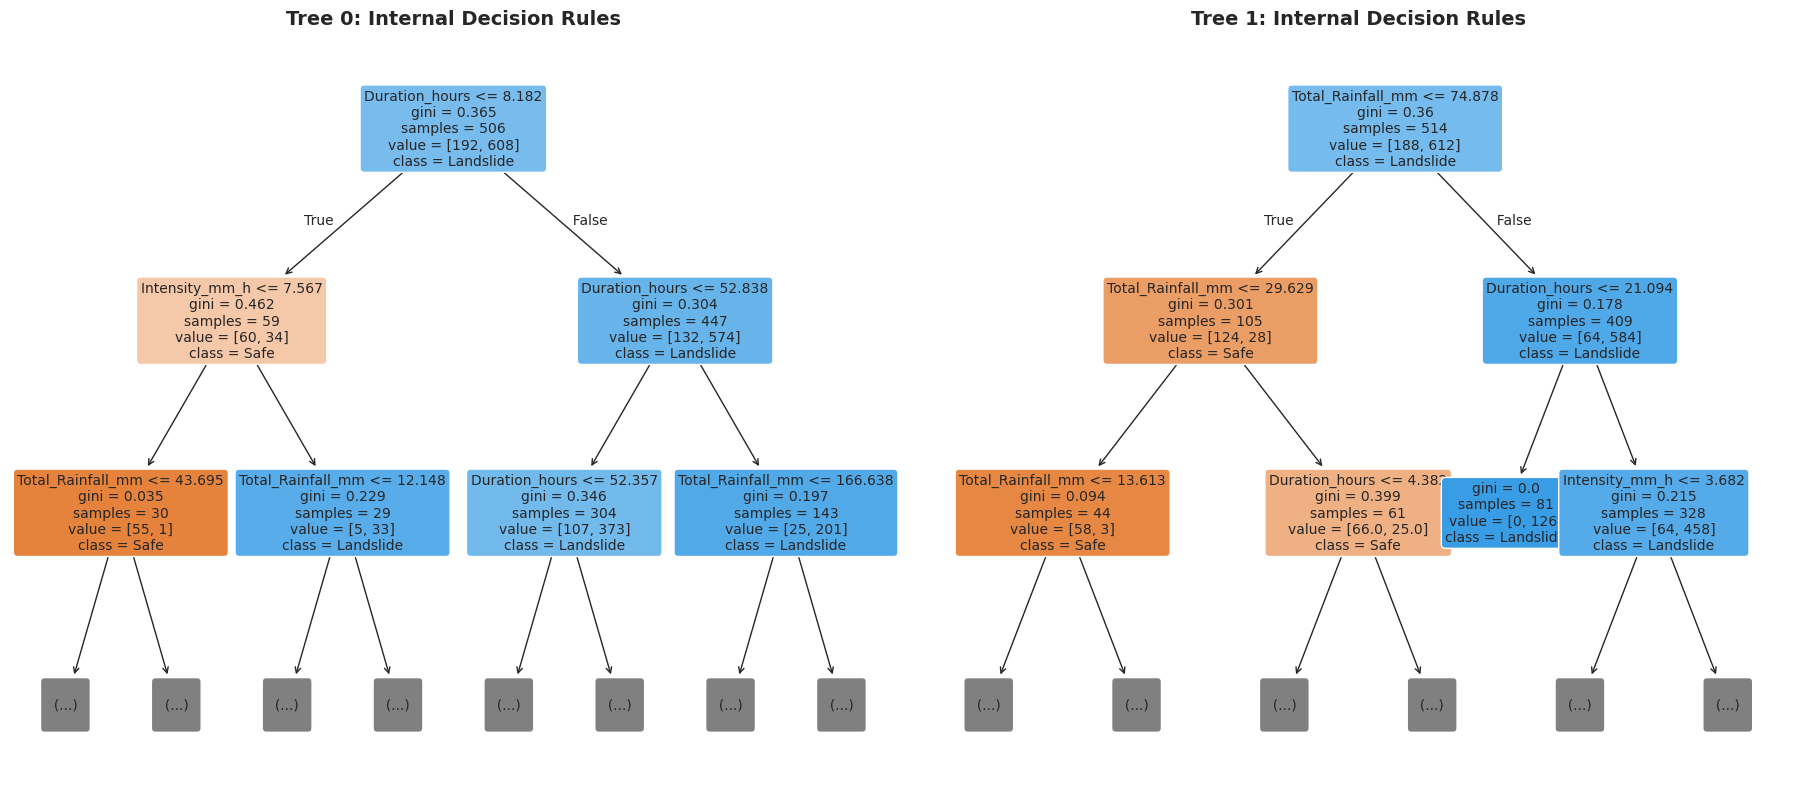

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8), layout='constrained')

# Plot the top levels of Tree 0
plot_tree(
    rf_model.estimators_[0],
    max_depth=2,
    feature_names=X.columns,
    class_names=['Safe', 'Landslide'],
    filled=True,
    rounded=True,
    ax=ax[0],
    fontsize=10
)
ax[0].set_title("Tree 0: Internal Decision Rules", fontsize=14, fontweight='bold')

# Plot the top levels of Tree 1
plot_tree(
    rf_model.estimators_[1],
    max_depth=2,
    feature_names=X.columns,
    class_names=['Safe', 'Landslide'],
    filled=True,
    rounded=True,
    ax=ax[1],
    fontsize=10
)
ax[1].set_title("Tree 1: Internal Decision Rules", fontsize=14, fontweight='bold')


**Important notes on the plot:**

**Orange** indicates a node where the majority of samples are Safe ($0$).

**Blue** indicates a node where the majority of samples are Landslide ($1$).

**The Root Node (The Top Box):** Look closely at the top box of both plots. Tree 0 might start its very first split using Intensity_mm_h, whereas Tree 1 might start its split using Total_Rainfall_mm. This is the direct result of Feature Randomization.

**Gini Impurity:** The gini value measures how mixed up the data points are at that node ($0.0$ means completely pure—all samples belong to one class). As you move down the tree branches, notice how the gini value drops, meaning the tree is successfully separating "Safe" storm events from "Landslide" storm events.

**Color Coding:** The boxes are color-coded by their majority class. In scikit-learn's default plotting palettes, deep blue/orange hues represent high confidence in a specific classification label, while pale white boxes indicate an even 50/50 mix where the tree needs to keep splitting to make up its mind.

# Step 5: Evaluate the Model
Let's see how well our forest captures the physical $I$-$D$ boundary on unseen test data.

In [12]:
# Predict on test data
y_pred = rf_model.predict(X_test)

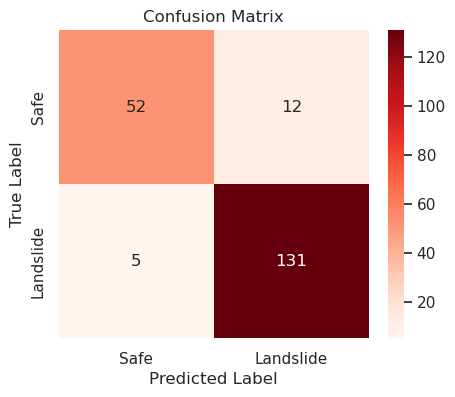

In [13]:
# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Safe', 'Landslide'], yticklabels=['Safe', 'Landslide'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

```
               ╔════════════════════════════════╗
               ║  TRUE (ACTUAL) CONDITION       ║
               ║    Positive     |   Negative   ║
╔══════════╦═══╬═════════════════╪══════════════╣
║          ║   ║                 ║              ║
║ PREDICTED║Pos║  True Positive  ║False Positive║
║          ║   ║     (TP)        ║     (FP)     ║
║ CONDITION╟───╕─────────────────┼──────────────╕
║          ║   ║                 ║              ║
║          ║Neg║  False Negative ║ True Negative║
║          ║   ║     (FN)        ║     (TN)     ║
╚══════════╩═══╩═════════════════╧══════════════╝
```

**Precision (Horizontal Slice)**

Precision focuses only on the Predicted Positive row. Out of everything the model claimed was positive, how much was actually true?

```
               ╔═════════════════╤═══════════════╗
 PREDICTED Pos ║  True Positive  │False Positive ║  ─►  TP / (TP + FP)
               ║     (TP)        │     (FP)      ║
               ╚═════════════════╧═══════════════╝
```

**Recall (Vertical Slice)**

Recall focuses only on the Actual Positive column. Out of all the real positive cases out there, how many did the model manage to find?

```
               ╔═════════════════╗
               ║ ACTUAL Positive ║
               ╠═════════════════╣
               ║                 ║
 PREDICTED Pos ║  True Positive  ║  ▲
               ║     (TP)        ║  │
               ╟─────────────────╢  │  TP / (TP + FN)
               ║                 ║  │
 PREDICTED Neg ║  False Negative ║  ▼
               ║     (FN)        ║
               ╚═════════════════╝
```

In [14]:
print('For Safe conditions:')
print('Precision: %.2f'%(37 / (37+10) ))
print('Recall: %.2f'%(37 / (37+8) ))

For Safe conditions:
Precision: 0.79
Recall: 0.82


In [15]:
# Print Evaluation Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.81      0.86        64
           1       0.92      0.96      0.94       136

    accuracy                           0.92       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.91      0.92      0.91       200



F1 score is the harmonic mean of precision and recall:

$$\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [16]:
print('F1 score for Safe conditions:')
print('%.2f'%(2 * ((37 / (37+10) ) * (37 / (37+8) ) ) / ( (37 / (37+10) ) + (37 / (37+8) ))))

F1 score for Safe conditions:
0.80


# Step 6: Feature Importance
In `scikit-learn`, Random Forests calculate **Gini Importance** (or Mean Decrease in Impurity). It tracks how much a feature's splits decrease the uncertainty across all $100$ trees.

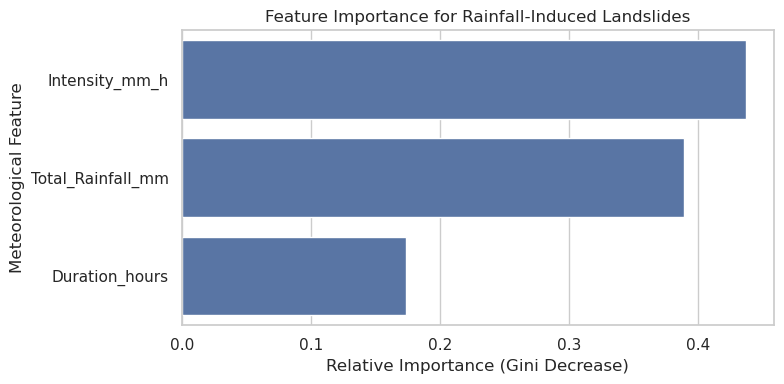

--- Feature Importance Ranking ---
          Feature  Importance
   Intensity_mm_h    0.437158
Total_Rainfall_mm    0.388998
   Duration_hours    0.173844


In [17]:
# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importances
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_df, legend=False)
plt.title('Feature Importance for Rainfall-Induced Landslides')
plt.xlabel('Relative Importance (Gini Decrease)')
plt.ylabel('Meteorological Feature')
plt.tight_layout()
plt.show()

print("--- Feature Importance Ranking ---")
print(feature_df.to_string(index=False))

# Step 7: Plot Predictions

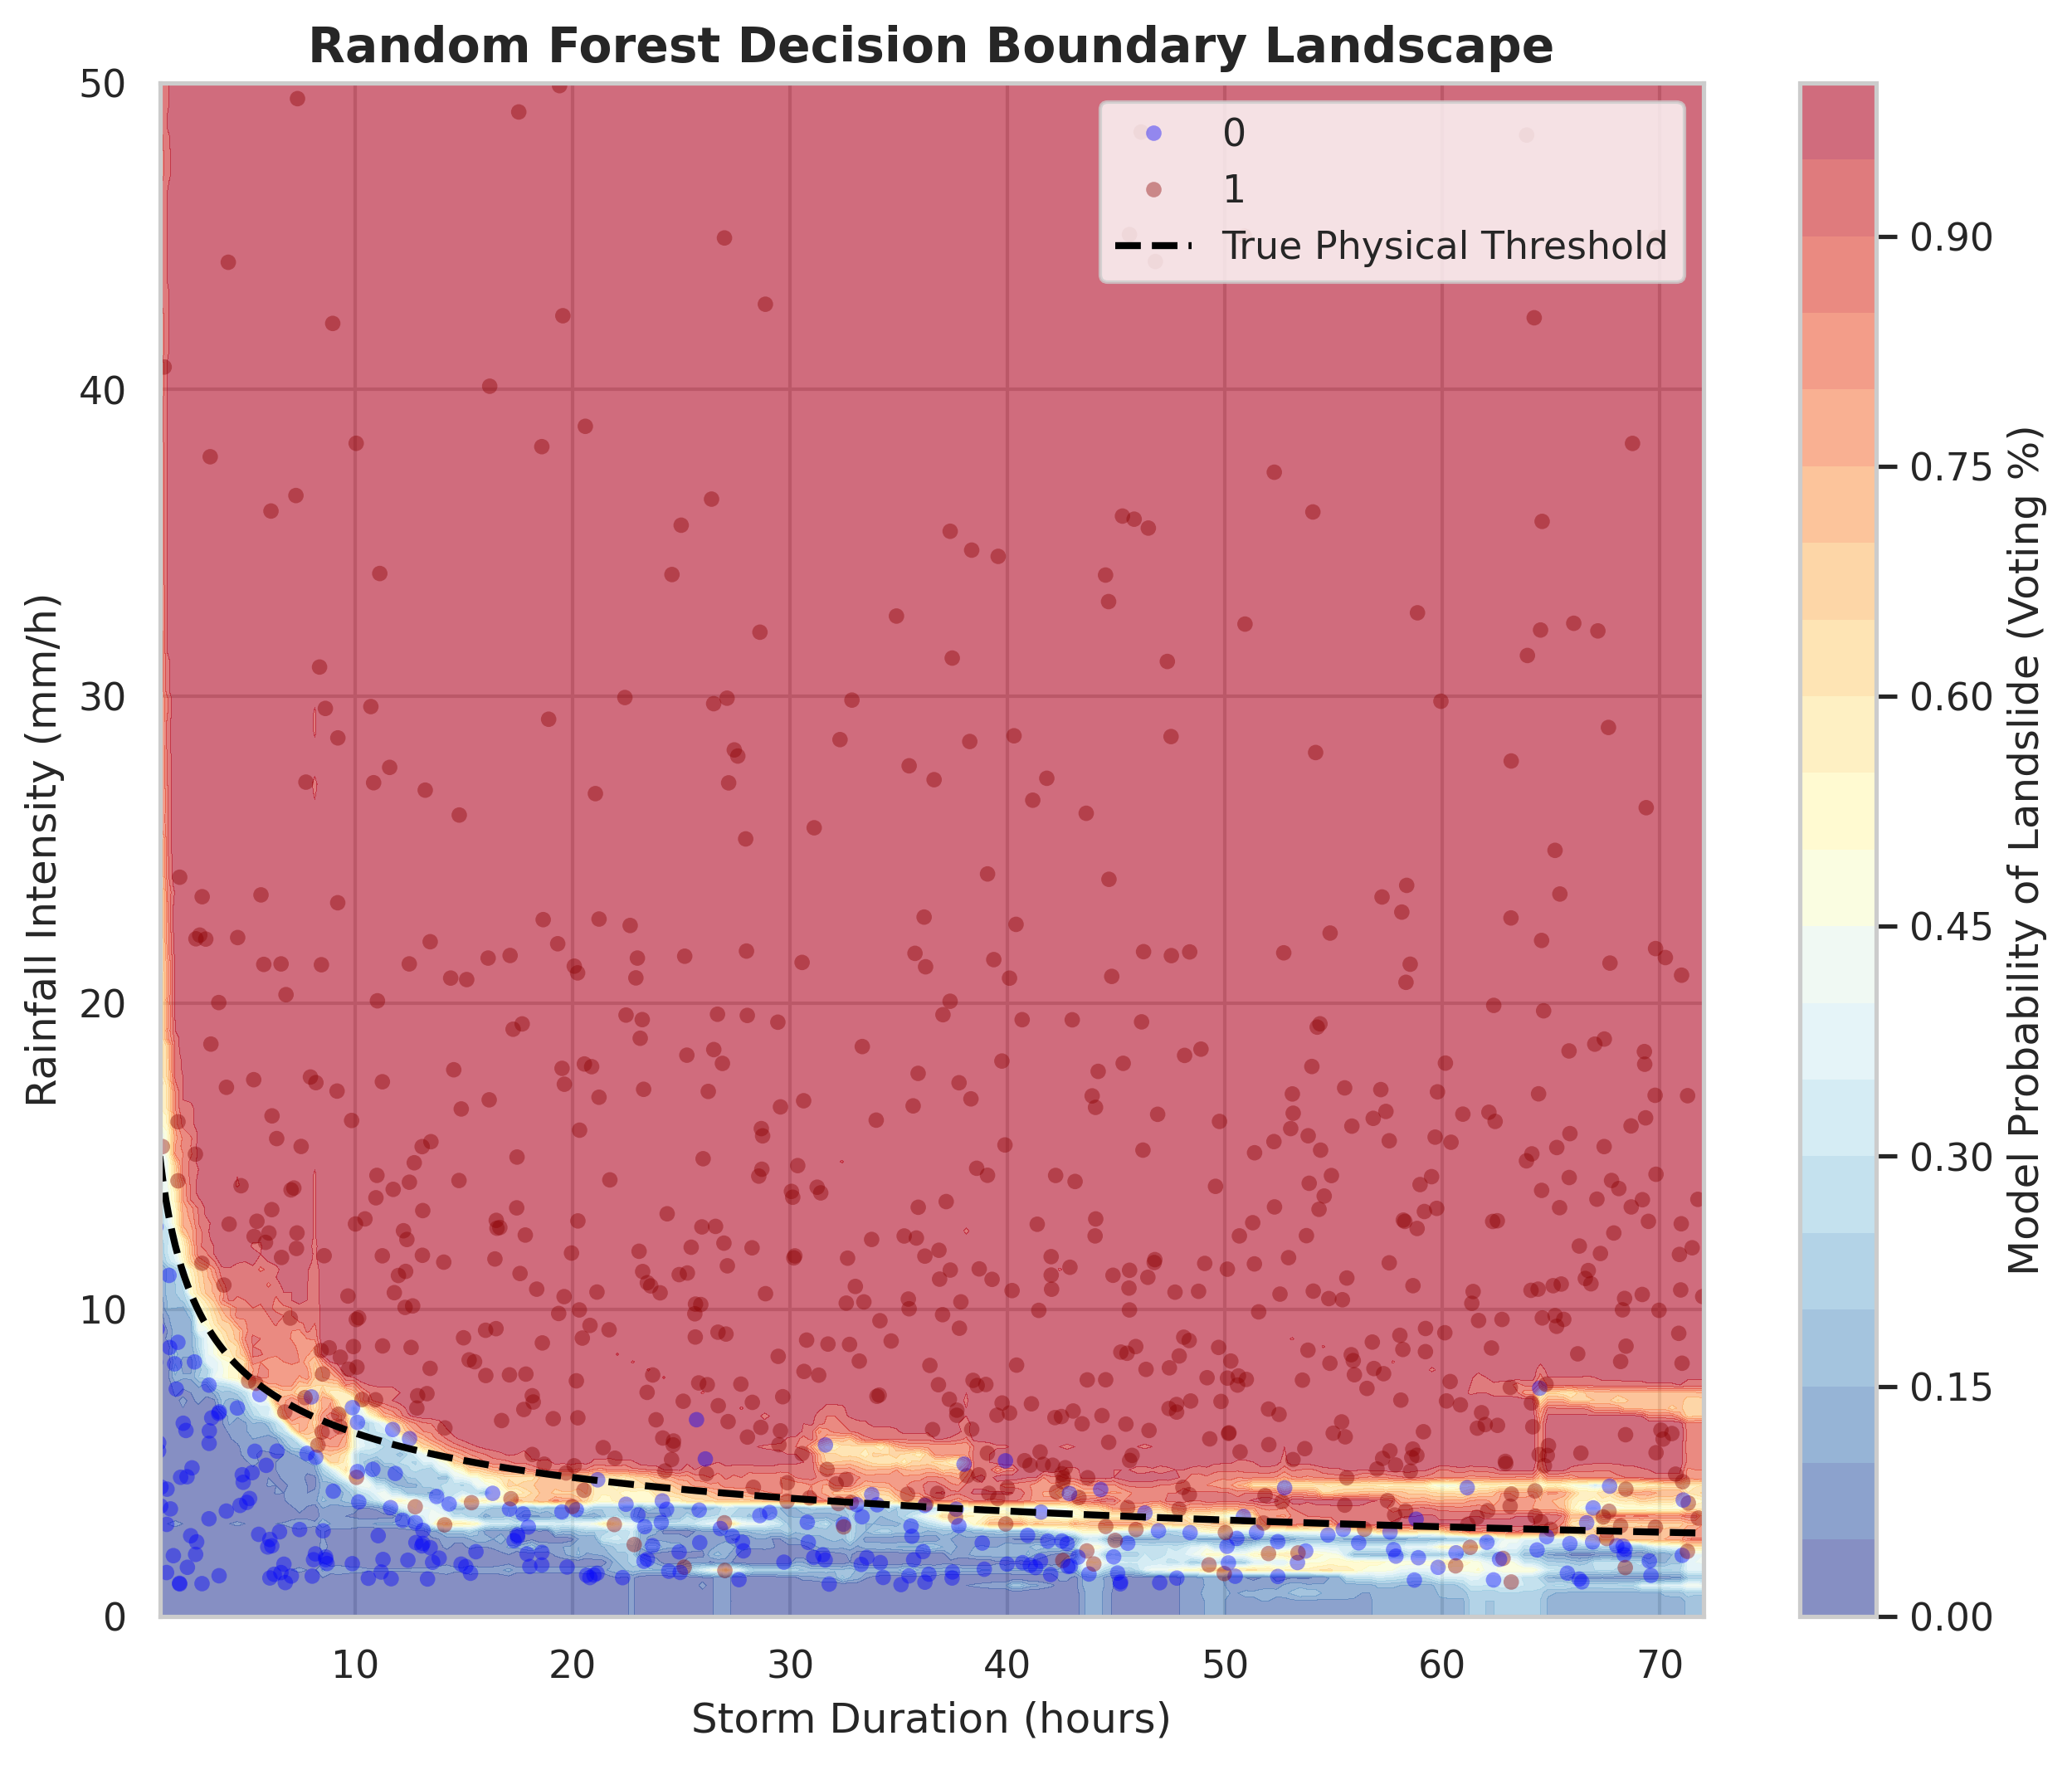

In [18]:
# 1. Create a dense 2D grid covering the full range of parameters
duration_range = np.linspace(1, 72, 200)
intensity_range = np.linspace(0, 50, 200)

# Create meshgrid matrices
D_grid, I_grid = np.meshgrid(duration_range, intensity_range)

# Flatten the grid arrays to create a query dataset for the model
grid_df = pd.DataFrame({
    'Duration_hours': D_grid.ravel(),
    'Intensity_mm_h': I_grid.ravel()
})
# Reconstruct the exact dependent feature the model expects
grid_df['Total_Rainfall_mm'] = grid_df['Duration_hours'] * grid_df['Intensity_mm_h']

# 2. Predict the outcome for every point on our map
# .predict() gives us 0 or 1, but .predict_proba() gives us the smooth voting percentage!
grid_predictions = rf_model.predict_proba(grid_df)[:, 1] # Probability of Landslide

# Reshape the 1D predictions back into the 2D grid shape for plotting
Z_grid = grid_predictions.reshape(D_grid.shape)

# 3. Plot the complete decision landscape
fig, ax = plt.subplots(1,1,figsize=(10, 8), dpi=300)

# Plot the model's full range of predictions as a background contour color map
contour = ax.contourf(D_grid, I_grid, Z_grid, levels=20, cmap='RdYlBu_r', alpha=0.6)
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Model Probability of Landslide (Voting %)', fontsize=12)

# Overlay the original true data points to see where the model succeeded/failed
sns.scatterplot(
    data=df, 
    x='Duration_hours', 
    y='Intensity_mm_h', 
    hue='Landslide', 
    palette={0: 'blue', 1: 'darkred'}, 
    alpha=0.4, 
    edgecolor='none',
    s=20,ax = ax,
)

# Plot the underlying theoretical physical equation line for comparison
theoretical_duration = np.linspace(1, 72, 500)
theoretical_threshold = 15 * (theoretical_duration ** -0.4)
ax.plot(theoretical_duration, theoretical_threshold, color='black', linestyle='--', linewidth=2, label='True Physical Threshold')

# Formatting labels
ax.set_title('Random Forest Decision Boundary Landscape', fontsize=14, fontweight='bold')
ax.set_xlabel('Storm Duration (hours)', fontsize=12)
ax.set_ylabel('Rainfall Intensity (mm/h)', fontsize=12)
ax.set_xlim(1, 72)
ax.set_ylim(0, 50)
# ax.set_yscale('log') # I-D curves are traditionally viewed on log scales
# ax.set_xscale('log')
ax.legend(loc='upper right')

# Step 8: Hyperparameter Tuning

(only showing for Random Forest)

In [19]:
from sklearn.model_selection import GridSearchCV

rf_accuracy = accuracy_score(y_test, rf_model.predict(X_test))

# 1. Define the parameter grid we want to search over
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [4, 6, 10, None], # None means trees grow until pure
    'min_samples_split': [2, 5, 10]
}

# 2. Initialize a base Random Forest model
base_rf = RandomForestClassifier(random_state=42)

# 3. Set up the Grid Search with 5-fold cross-validation
# cv=5 means the data is split into 5 parts, training and validating 5 times for every combination
grid_search = GridSearchCV(estimator=base_rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 4. Run the grid search on our training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print("--- Grid Search Results ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

--- Grid Search Results ---
Best Hyperparameters: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation Accuracy: 92.88%


## Visualize the impact of hyperparameter tuning

In [20]:
# 1. Extract the optimized model
best_rf_model = grid_search.best_estimator_

# 2. Predict on the test set with the tuned model
y_pred_tuned = best_rf_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

# 3. Print comparison
print(f"Original Baseline Model Accuracy: {rf_accuracy * 100:.2f}%")
print(f"Tuned 'Best' Model Accuracy:       {tuned_accuracy * 100:.2f}%")

Original Baseline Model Accuracy: 91.50%
Tuned 'Best' Model Accuracy:       91.50%


## Comparing results

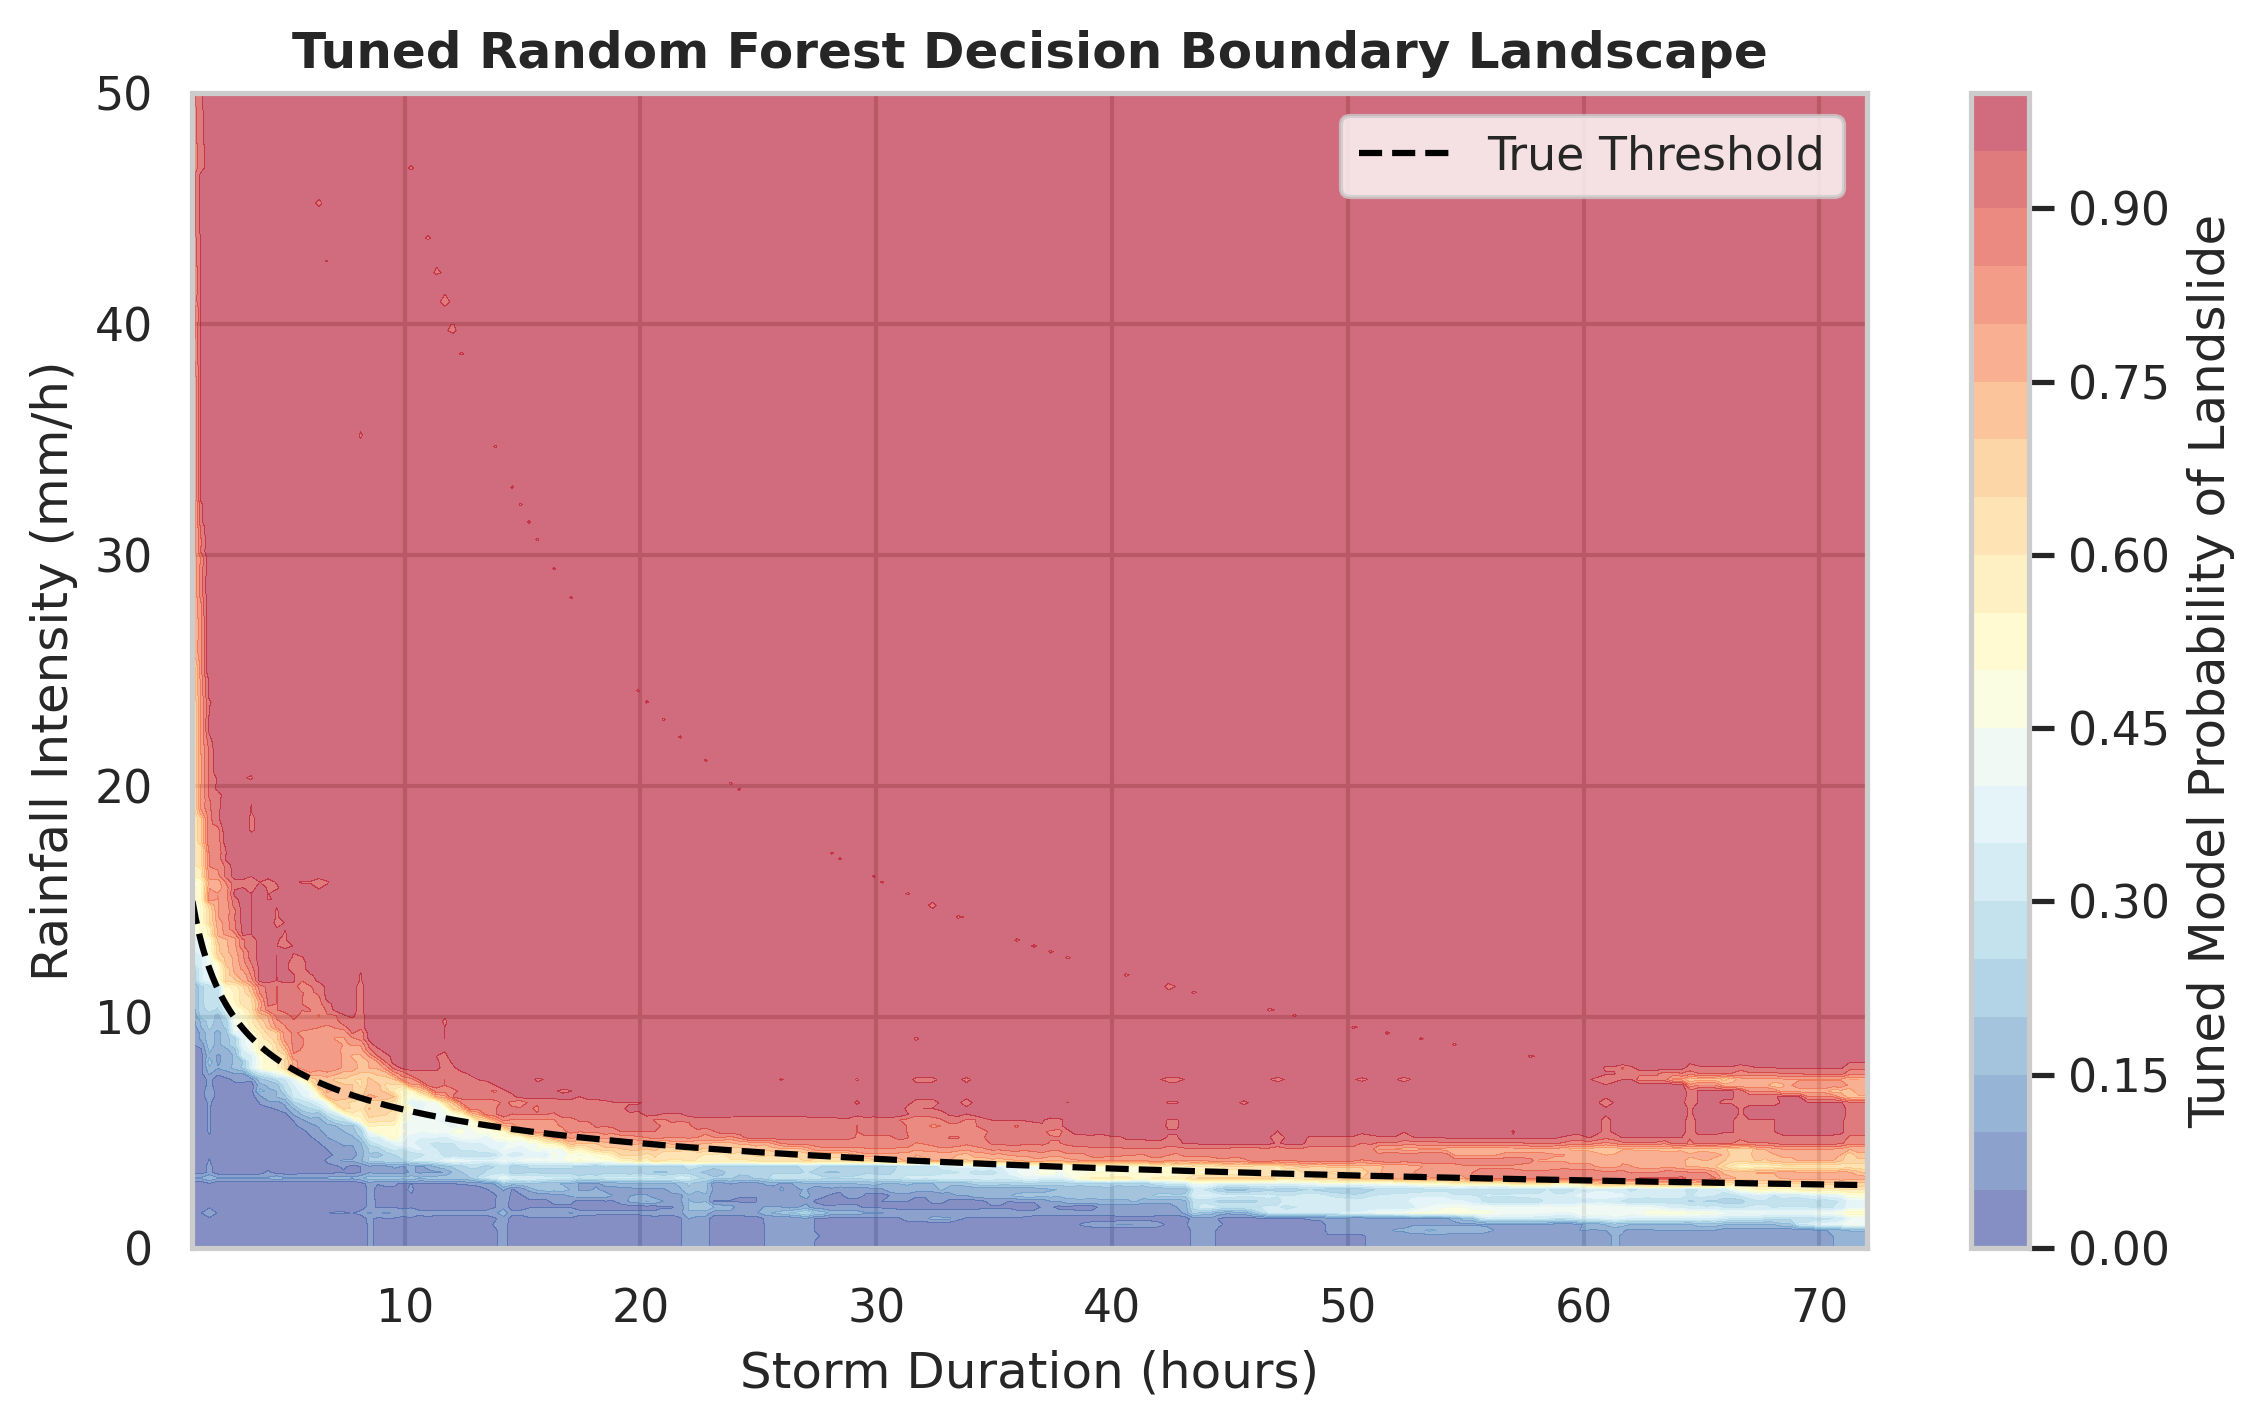

In [21]:
# Predict using the newly tuned model on our dense grid
tuned_predictions = best_rf_model.predict_proba(grid_df)[:, 1]
Z_tuned = tuned_predictions.reshape(D_grid.shape)

plt.figure(figsize=(9, 5), dpi=300)
contour = plt.contourf(D_grid, I_grid, Z_tuned, levels=20, cmap='RdYlBu_r', alpha=0.6)
plt.colorbar(contour, label='Tuned Model Probability of Landslide')

# Overlay true threshold line
plt.plot(theoretical_duration, theoretical_threshold, color='black', linestyle='--', linewidth=1.5, label='True Threshold')

plt.title('Tuned Random Forest Decision Boundary Landscape', fontsize=12, fontweight='bold')
plt.xlabel('Storm Duration (hours)')
plt.ylabel('Rainfall Intensity (mm/h)')
plt.xlim(1, 72)
plt.ylim(0, 50)
plt.legend()

### Plot side-by-side

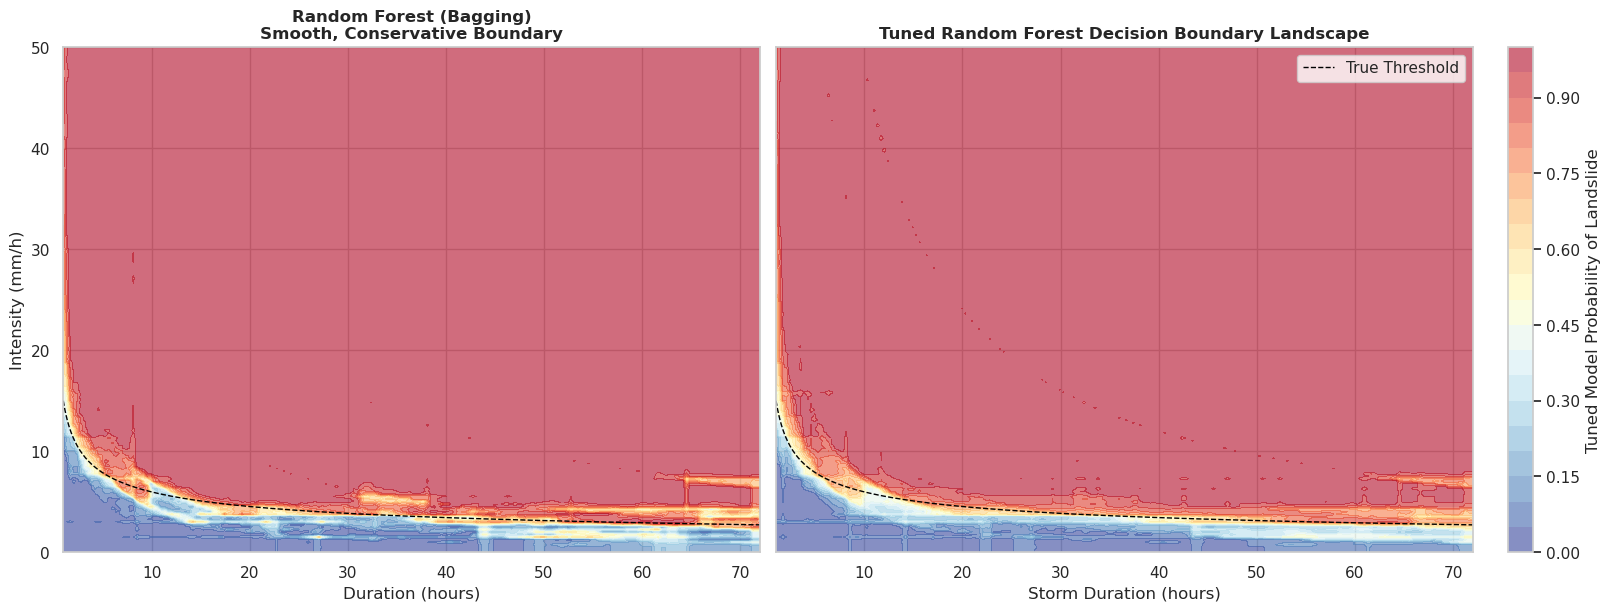

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True, layout='constrained')

# Random Forest Plot
ax[0].contourf(D_grid, I_grid, Z_grid, levels=20, cmap='RdYlBu_r', alpha=0.6)
ax[0].set_title('Random Forest (Bagging)\nSmooth, Conservative Boundary', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Duration (hours)')
ax[0].set_ylabel('Intensity (mm/h)')
ax[0].set_xlim(1, 72)
ax[0].set_ylim(0, 50)
ax[0].plot(theoretical_duration, theoretical_threshold, color='black', linestyle='--', linewidth=1, label='True Physical Threshold')


contour = ax[1].contourf(D_grid, I_grid, Z_tuned, levels=20, cmap='RdYlBu_r', alpha=0.6)
plt.colorbar(contour, label='Tuned Model Probability of Landslide')
ax[1].plot(theoretical_duration, theoretical_threshold, color='black', linestyle='--', linewidth=1, label='True Threshold')
ax[1].set_title('Tuned Random Forest Decision Boundary Landscape', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Storm Duration (hours)')
ax[1].set_xlim(1, 72)
ax[1].set_ylim(0, 50)
ax[1].legend()

# Difference between Random Forest and XGBoost

**The Core Difference: How Trees Learn**

1. **Random Forest (Independent Democracy)**
In a Random Forest, every tree is trained on a different random subset of data (a bootstrap sample). The trees do not talk to each other. They each do their best to map out the entire landslide threshold, and then they all vote at the end. If one tree overfits and gets a noisy region wrong, the other 99 trees correct it through a majority vote.

2. **XGBoost (Sequential Teamwork)**
XGBoost does not build independent trees. Instead, it builds trees sequentially in a chain:

Tree 1 makes a crude guess at the landslide boundary. It gets many hard, noisy points wrong.

Tree 2 is trained specifically on the errors (residuals) made by Tree 1. It gives extra weight to the landslide events that Tree 1 missed.

Tree 3 is trained to fix the lingering errors left by Tree 1 and Tree 2 combined.

This process repeats hundreds of times. Each tree acts like a specialized specialist correcting the blind spots of its predecessors.


In [23]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Initialize and train a Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# 2. Evaluate both on the test set
rf_accuracy = accuracy_score(y_test, rf_model.predict(X_test))
gb_accuracy = accuracy_score(y_test, gb_model.predict(X_test))

print(f"Random Forest Test Accuracy: {rf_accuracy * 100:.2f}%")
print(f"Gradient Boosting Test Accuracy: {gb_accuracy * 100:.2f}%")

Random Forest Test Accuracy: 91.50%
Gradient Boosting Test Accuracy: 91.50%


Text(0.5, 0, 'Storm Duration (hours)')

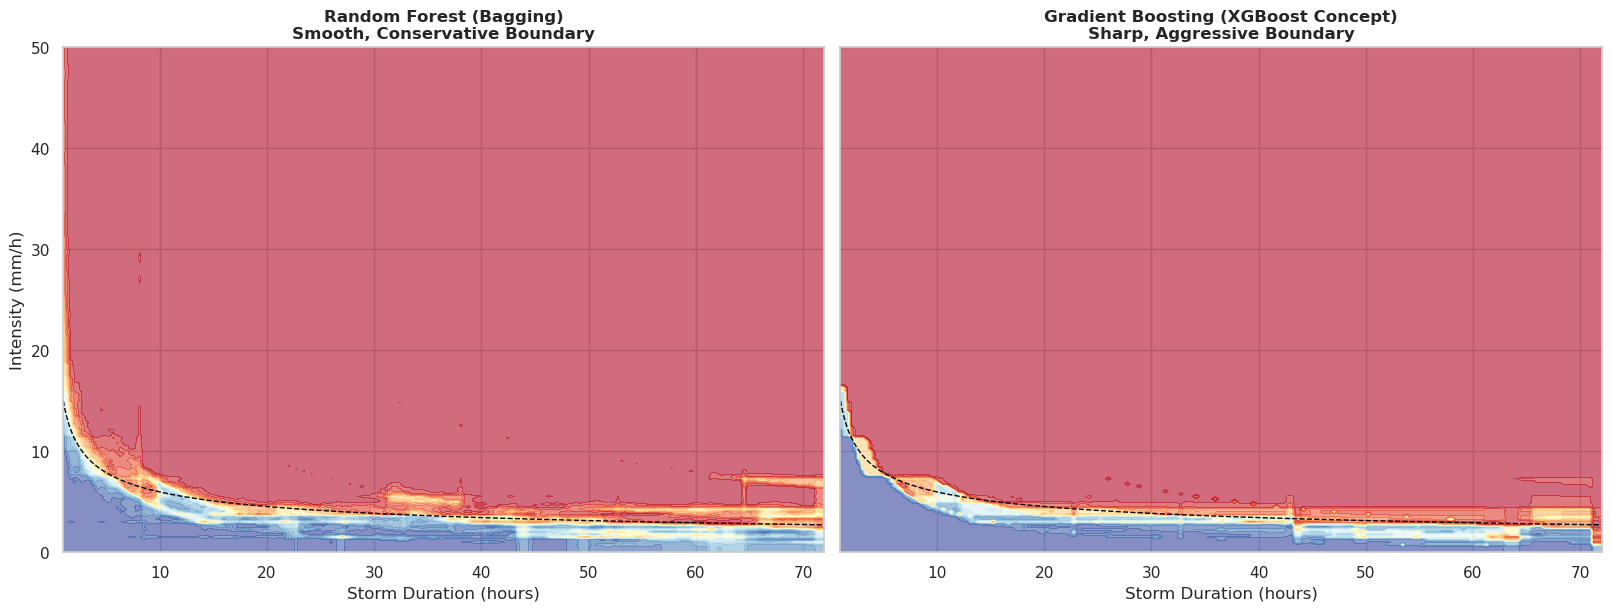

In [24]:
# Predict using the Boosting model on our dense grid from Step 7
gb_predictions = gb_model.predict_proba(grid_df)[:, 1]
Z_gb = gb_predictions.reshape(D_grid.shape)

# Plot side-by-side comparison
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True, layout='constrained')

# Random Forest Plot
ax[0].contourf(D_grid, I_grid, Z_grid, levels=20, cmap='RdYlBu_r', alpha=0.6)
ax[0].set_title('Random Forest (Bagging)\nSmooth, Conservative Boundary', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Storm Duration (hours)')
ax[0].set_ylabel('Intensity (mm/h)')
ax[0].set_xlim(1, 72)
ax[0].set_ylim(0, 50)
ax[0].plot(theoretical_duration, theoretical_threshold, color='black', linestyle='--', linewidth=1, label='True Physical Threshold')

# Gradient Boosting Plot
ax[1].contourf(D_grid, I_grid, Z_gb, levels=20, cmap='RdYlBu_r', alpha=0.6)
ax[1].plot(theoretical_duration, theoretical_threshold, color='black', linestyle='--', linewidth=1, label='True Physical Threshold')
ax[1].set_title('Gradient Boosting (XGBoost Concept)\nSharp, Aggressive Boundary', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Storm Duration (hours)')

**Limiting the `max_depth` will lead to a smoother boundary transition.**

**Why Gradient Boosting often scores higher:** Because it focuses intensely on hard-to-classify edge cases, it can squeeze out a slightly higher accuracy score on complex physical thresholds.

**The Catch:** Because XGBoost focuses heavily on fixing mistakes, it can accidentally start memorizing noise or outliers if it is allowed to run for too many iterations. Random Forests are much harder to overfit and generally require far less hyperparameter tuning to get "good enough" results safely.